# Assessment 2 — Move AusVille Urban Mobility Analysis
**Unit:** Introduction to Data Science  
**Dataset:** Monthly Average Patronage by Day Type and Mode

---
## Section 1: Data Preparation

### Step 1 — Import libraries

Before we do anything, we need to load the tools (called **libraries**) that Python uses for data work.

- **pandas** (`pd`) — the main library for working with tables of data. Think of it like Excel but in Python.
- **numpy** (`np`) — used for maths and numbers behind the scenes.

The two `pd.set_option` lines just make the output look cleaner by showing all columns and rounding decimals to 2 places.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

### Step 2 — Load the dataset

Here we tell Python where the CSV file is stored and read it into a **DataFrame** (a table with rows and columns).

We call it `df_raw` — the "raw" version before any cleaning. This is good practice so we always have the original to go back to if something goes wrong.

**What to check in the output:** the shape tells you how many rows and columns loaded. We expect 4,300 rows and 7 columns.

In [2]:
file_path = "/Users/apple/INTRO TO DATASCIENCE/Data/Dataset- Monthly average patronage by day type and by mode.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully")
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded successfully
Shape: 4300 rows x 7 columns


,Year,Month,Month_name,Day_of_week,Day_type,Mode,Pax_daily
0,2018,1,Jan,Friday,School Holiday Weekday,MetroBus,268350
1,2018,1,Jan,Friday,School Holiday Weekday,MetroTrain,570700
2,2018,1,Jan,Friday,School Holiday Weekday,RegionalBus,21550
3,2018,1,Jan,Friday,School Holiday Weekday,RegionalTrain,43700
4,2018,1,Jan,Friday,School Holiday Weekday,Tram,529250


### Step 3 — Inspect the structure

Before cleaning anything, we look at what we have. This is like opening a new spreadsheet and checking it makes sense.

- `.dtypes` — shows the **data type** of each column (number, text, etc.). We want Year, Month, and Pax_daily to be numbers, not text.
- `.describe()` — gives summary statistics (min, max, average, etc.) for every column.
- `.info()` — shows column names, types, and how many non-null (non-missing) values there are.

**What to look for:** any columns with unexpected types, or counts less than 4,300 which would mean missing values.

In [3]:
print("Columns:", df_raw.columns.tolist())
print()
print(df_raw.dtypes)
print()
df_raw.describe(include="all")

Columns: ['Year', 'Month', 'Month_name', 'Day_of_week', 'Day_type', 'Mode', 'Pax_daily']

Year           int64
Month          int64
Month_name       str
Day_of_week      str
Day_type         str
Mode             str
Pax_daily      int64
dtype: object



,Year,Month,Month_name,Day_of_week,Day_type,Mode,Pax_daily
count,4300.00,4300.00,4300,4300,4300,4300,4300.00
unique,NaN,NaN,12,7,3,5,NaN
top,NaN,NaN,Apr,Thursday,Normal Weekday,MetroBus,NaN
freq,NaN,NaN,480,680,2265,860,NaN
mean,2021.44,6.55,NaN,NaN,NaN,NaN,240732.31
std,2.27,3.38,NaN,NaN,NaN,NaN,226797.34
min,2018.00,1.00,NaN,NaN,NaN,NaN,1900.00
25%,2019.00,4.00,NaN,NaN,NaN,NaN,37800.00
50%,2021.00,7.00,NaN,NaN,NaN,NaN,165375.00
75%,2023.00,9.00,NaN,NaN,NaN,NaN,406562.50


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Year         4300 non-null   int64
 1   Month        4300 non-null   int64
 2   Month_name   4300 non-null   str  
 3   Day_of_week  4300 non-null   str  
 4   Day_type     4300 non-null   str  
 5   Mode         4300 non-null   str  
 6   Pax_daily    4300 non-null   int64
dtypes: int64(3), str(4)
memory usage: 235.3 KB


### Step 4 — Check for data quality issues

Now we specifically look for common problems in the data:

1. **Missing values** — empty cells that could break our analysis.
2. **Duplicate rows** — the same row recorded twice, which would skew averages.
3. **Unexpected category values** — e.g. if `Mode` had a typo like `"MetroBuss"`, it would appear as a 6th mode.
4. **Anomalous `Pax_daily` values** — zeros, negatives, or IQR outliers that could distort results.

**Decision rule:** if anomalies reflect genuine events (e.g. COVID lockdowns) we retain them and document; imputation is only applied if values are clearly erroneous.

In [5]:
print("Missing values:")
print(df_raw.isnull().sum())
print()
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print()
for col in ["Day_type", "Mode", "Day_of_week"]:
    print(f"Unique {col}: {df_raw[col].unique().tolist()}")
    print()

# Pax_daily anomaly check
q1 = df_raw["Pax_daily"].quantile(0.25)
q3 = df_raw["Pax_daily"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
n_zeros     = (df_raw["Pax_daily"] == 0).sum()
n_negative  = (df_raw["Pax_daily"] < 0).sum()
n_outliers  = ((df_raw["Pax_daily"] < lower_fence) | (df_raw["Pax_daily"] > upper_fence)).sum()
print(f"Pax_daily anomaly check:")
print(f"  Zero values    : {n_zeros}")
print(f"  Negative values: {n_negative}")
print(f"  IQR outliers   : {n_outliers}  (fence: {lower_fence:.0f} to {upper_fence:.0f})")
print("Decision: outliers reflect real events (COVID, peaks) — no imputation applied.")


Missing values:
Year           0
Month          0
Month_name     0
Day_of_week    0
Day_type       0
Mode           0
Pax_daily      0
dtype: int64

Duplicate rows: 0

Unique Day_type: ['School Holiday Weekday', 'Normal Weekday', 'Weekend']

Unique Mode: ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']

Unique Day_of_week: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

Pax_daily anomaly check:
  Zero values    : 0
  Negative values: 0
  IQR outliers   : 0  (fence: -515344 to 959706)
Decision: outliers reflect real events (COVID, peaks) — no imputation applied.


### Step 5 — Clean and convert data types

Now we fix any issues found in Step 4. We work on a **copy** of the raw data (`df = df_raw.copy()`) so the original is never changed.

- **`.str.strip().str.title()`** — removes hidden spaces and standardises capitalisation.
- **`astype("category")`** — tells pandas `Day_of_week`, `Day_type`, and `Mode` have a fixed set of labels (saves memory, enables faster grouping).
- **`astype(int)`** — explicitly enforces `Year` and `Month` as integers.
- **`.drop_duplicates()`** — removes any identical repeated rows.
- **`.dropna()`** — removes rows where key columns are empty.

**What to look for:** `Day_of_week`, `Day_type`, and `Mode` should show dtype `category` in the output.

In [6]:
df = df_raw.copy()

# Strip whitespace and standardise to title-case
for col in ["Month_name", "Day_of_week", "Day_type", "Mode"]:
    df[col] = df[col].str.strip().str.title()

# Enforce integer types for Year and Month
df["Year"]  = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)

# Convert label columns to categorical dtype
for col in ["Day_of_week", "Day_type", "Mode"]:
    df[col] = df[col].astype("category")

# Remove duplicates and rows missing key fields
df = df.drop_duplicates()
df = df.dropna(subset=["Year", "Month", "Mode", "Pax_daily"])

print(f"Cleaned shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
print("Dtypes after cleaning:")
print(df.dtypes)


Cleaned shape: 4300 rows x 7 columns

Dtypes after cleaning:
Year              int64
Month             int64
Month_name          str
Day_of_week    category
Day_type       category
Mode           category
Pax_daily         int64
dtype: object


### Step 6 — Feature Engineering

**Feature engineering** means creating new columns from existing ones to make analysis easier or more meaningful.

New columns added:

- **`MonthStart`** — first day of each Year/Month (e.g. `2020-03-01`) for time-series plots.
- **`Period`** — 3-level COVID-era label: `Pre-2020`, `2020-2021`, or `Post-2021`.
- **`Is_Weekday`** — `True` if `Day_of_week` is Monday–Friday, `False` otherwise.
- **`Rolling_3m_mean`** — 3-month rolling average of `Pax_daily` within each `Mode × Day_type` group.
- **`Period_category`** — simplified Day_type labels (`Weekday`, `School Holiday`, `Weekend`).
- **`COVID_period`** — boolean flag for 2020–2021.
- **`Network_type`** — `Metro` vs `Regional` grouping.

**What to look for:** `Period` has exactly 3 unique values; `Is_Weekday` is `True` for Mon–Fri rows only; `Rolling_3m_mean` should be slightly smoother than raw `Pax_daily`.

In [7]:
# MonthStart — first day of each Year/Month
df["MonthStart"] = pd.to_datetime(df[["Year", "Month"]].assign(Day=1))

# Period: Pre-2020 / 2020-2021 / Post-2021
def assign_period(year):
    if year < 2020:
        return "Pre-2020"
    elif year <= 2021:
        return "2020-2021"
    else:
        return "Post-2021"

df["Period"] = df["Year"].apply(assign_period)
print("Period value counts:")
print(df["Period"].value_counts().sort_index())
print()

# Is_Weekday: True for Monday-Friday
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
df["Is_Weekday"] = df["Day_of_week"].isin(weekdays)
print("Is_Weekday distribution:")
print(df["Is_Weekday"].value_counts())
print()

# Rolling 3-month mean by Mode and Day_type
df = df.sort_values(["Mode", "Day_type", "MonthStart"]).reset_index(drop=True)
df["Rolling_3m_mean"] = (
    df.groupby(["Mode", "Day_type"], observed=True)["Pax_daily"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Period_category — simplified Day_type labels
def classify_period(day_type):
    s = str(day_type)
    if "School Holiday" in s:
        return "School Holiday"
    elif "Weekday" in s or "Normal" in s:
        return "Weekday"
    elif "Weekend" in s:
        return "Weekend"
    return "Other"

df["Period_category"] = df["Day_type"].apply(classify_period)

# COVID_period boolean flag
df["COVID_period"] = df["Year"].isin([2020, 2021])

# Network_type: Metro vs Regional
df["Network_type"] = df["Mode"].apply(
    lambda x: "Metro" if "Metro" in str(x) or "Tram" in str(x) else "Regional"
)

print("All engineered features added. Preview:")
df[["MonthStart", "Period", "Is_Weekday", "Rolling_3m_mean",
    "Period_category", "COVID_period", "Network_type"]].head(10)


Period value counts:
Period
2020-2021    1120
Post-2021    2100
Pre-2020     1080
Name: count, dtype: int64

Is_Weekday distribution:
Is_Weekday
True     3350
False     950
Name: count, dtype: int64

All engineered features added. Preview:


,MonthStart,Period,Is_Weekday,Rolling_3m_mean,Period_category,COVID_period,Network_type
0,2018-01-01,Pre-2020,True,308450.00,Weekday,False,Metro
1,2018-01-01,Pre-2020,True,334125.00,Weekday,False,Metro
2,2018-01-01,Pre-2020,True,356166.67,Weekday,False,Metro
3,2018-02-01,Pre-2020,True,403233.33,Weekday,False,Metro
4,2018-02-01,Pre-2020,True,437550.00,Weekday,False,Metro
5,2018-02-01,Pre-2020,True,457716.67,Weekday,False,Metro
6,2018-02-01,Pre-2020,True,466483.33,Weekday,False,Metro
7,2018-02-01,Pre-2020,True,468366.67,Weekday,False,Metro
8,2018-03-01,Pre-2020,True,476150.00,Weekday,False,Metro
9,2018-03-01,Pre-2020,True,477033.33,Weekday,False,Metro


### Step 7 — Summary statistics

Now the data is clean, we explore it with summary statistics to understand patterns before visualising anything.

- **`.describe()`** — gives the min, max, average, and spread of daily passengers (`Pax_daily`).
- **`groupby("Mode")`** — breaks the data down by transport type so we can compare MetroBus vs MetroTrain vs Tram etc.
- **`groupby("Period_category")`** — compares weekday vs weekend vs school holiday patronage.
- **`groupby("Year")`** — shows the year-on-year trend. We expect a clear dip in 2020-2021 due to COVID.

**What to look for:** which mode has the highest average patronage? Does patronage drop noticeably in 2020-2021?

In [8]:
df["Pax_daily"].describe()

count     4300.00
mean    240732.31
std     226797.34
min       1900.00
25%      37800.00
50%     165375.00
75%     406562.50
max     927650.00
Name: Pax_daily, dtype: float64

In [9]:
df.groupby("Mode")["Pax_daily"].agg(["mean", "median", "std", "min", "max"]).round(0)

,mean,median,std,min,max
Mode,,,,,
Metrobus,281975.00,305975.00,122362.00,22750,503750
Metrotrain,458138.00,458400.00,225300.00,31950,927650
Regionalbus,27079.00,28950.00,11578.00,2350,47200
Regionaltrain,39933.00,41100.00,18942.00,1900,76850
Tram,396537.00,416325.00,178339.00,22750,792550


In [10]:
df.groupby("Period_category")["Pax_daily"].agg(["mean", "median", "std"]).round(0)

,mean,median,std
Period_category,,,
Weekday,281347.00,260050.00,247705.00
School Holiday,238331.00,195150.00,219508.00
Weekend,146640.00,122975.00,137069.00


In [11]:
# Year-on-year average -- shows COVID dip
df.groupby("Year")["Pax_daily"].mean().round(0)

Year
2018   335997.00
2019   334615.00
2020   119098.00
2021   136242.00
2022   209552.00
2023   255160.00
2024   275661.00
2025   271396.00
Name: Pax_daily, dtype: float64

### Step 8 — Export cleaned dataset

We save the cleaned and enriched DataFrame as a new CSV file. This means we do not have to repeat all the cleaning steps every time — we can just load the clean version directly in future notebooks.

The original raw file is left untouched.

In [12]:
output_path = "/Users/apple/INTRO TO DATASCIENCE/Data/ausville_patronage_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"Final shape: {df.shape}")

Cleaned dataset saved to: /Users/apple/INTRO TO DATASCIENCE/Data/ausville_patronage_cleaned.csv
Final shape: (4300, 14)


---
## Section 2: Analysis

This section covers all required analytical components:
- **A. Descriptive Analytics** — summary tables, trend lines, heatmap, bar charts with confidence intervals
- **B. Probability Distributions & Modelling** — distribution checks, Q-Q plots, normality, regression, probability statement
- **C. Inferential Statistics** — two-sample tests, ANOVA, effect sizes, 95% confidence intervals

> Note: Sections A, B, and C are completed in Python/pandas. Power BI (Section D) is handled separately.

### Step 9 — Import analysis libraries

Before we can draw any charts or run any statistical tests, we need to load the right Python libraries. Think of these as specialist toolkits — each one handles a different job.

**Why each library?**
- `matplotlib.pyplot` — the base charting engine in Python. Everything else draws on top of it.
- `matplotlib.dates` — an add-on to matplotlib that formats dates nicely on the x-axis of time-series charts.
- `seaborn` — a higher-level charting library built on matplotlib. It makes statistical plots (heatmaps, distribution charts, bar charts with confidence intervals) much easier to write.
- `scipy.stats` — a library full of statistical functions. We use it for normality tests (Shapiro-Wilk), distribution fitting (normal CDF), Q-Q plots, and non-parametric tests (Mann-Whitney U, Kruskal-Wallis).
- `sklearn.linear_model.LinearRegression` — from scikit-learn. Used to fit a straight-line trend through the monthly data to estimate the long-run growth or decline rate.
- `sklearn.metrics.r2_score` — calculates R² (how well the regression line fits the data; 1.0 = perfect fit, 0.0 = no fit).
- `warnings` — used to suppress minor warnings that clutter the output without affecting results. 

**Key syntax:**
- `sns.set_theme(style="whitegrid", palette="muted")` — sets a consistent visual style for all seaborn charts: white background with faint grid lines, muted colour palette.
- `plt.rcParams["figure.dpi"] = 110` — sets the resolution for all figures (110 dots per inch = clear but not oversized).

**What to look for:** If this cell runs without error, all required libraries are installed and ready to use.

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, ttest_ind, norm, probplot, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Analysis libraries loaded.")

Analysis libraries loaded.


### Section A — Descriptive Analytics

Required:
- **A1:** Summary tables — mean/median/std of Pax_daily by Mode, Day_type, Day_of_week, and Period
- **A2:** Trend lines — time-series of monthly Pax_daily (overall and split by Mode)
- **A3:** Heatmap — Day_of_week vs Transport Mode (average Pax_daily)
- **A4:** Bar charts with 95% CI error bars — Pax_daily by Mode and Day_type

### Step A1 — Summary tables

Before drawing any charts, it helps to have the actual numbers in front of us. Summary tables give us the mean (average), median (middle value), and standard deviation (spread) for each group. By comparing these across modes, day types, days of the week, and time periods, we get a factual foundation for every claim we make later in the report.

**Why mean AND median?**
If a dataset is skewed (for example, a few extremely high passenger days pulling the average up), the mean can be misleading. The median is not affected by outliers. Reporting both lets us spot skew — if mean is much higher than median, the data has a long upper tail.

**Why standard deviation?**
Standard deviation (std) measures how spread out the values are. A high std means patronage varies a lot day-to-day; a low std means it is consistent. This matters for service planning — high variation means you need more buffer capacity.

**Key syntax explained line by line:**
- `df.groupby("Mode", observed=True)["Pax_daily"]` — split the DataFrame into groups by Mode, then focus on the Pax_daily column. `observed=True` tells pandas to only show categories that actually appear in the data (ignores empty categories).
- `.agg(["mean", "median", "std", "min", "max"])` — calculate all five statistics at once for each group.
- `.round(0)` — round to whole numbers, since fractional passengers don't make sense.
- `reindex(period_order)` — reorder the Period rows into chronological order (Pre-2020 → 2020-2021 → Post-2021) rather than alphabetical order.

**What to look for:** Notice which Mode has the highest average patronage, whether weekdays or weekends dominate, and how the COVID period (2020-2021) compares to before and after.

In [14]:
# A1: Summary tables — mean/median/std by Mode, Day_type, Day_of_week, and Period

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
period_order = ["Pre-2020", "2020-2021", "Post-2021"]

print("=== A1: Summary by Mode ===")
display(df.groupby("Mode", observed=True)["Pax_daily"]
        .agg(["mean", "median", "std", "min", "max"]).round(0))

print("\n=== A2: Summary by Day_type ===")
display(df.groupby("Day_type", observed=True)["Pax_daily"]
        .agg(["mean", "median", "std"]).round(0))

print("\n=== A3: Summary by Day_of_week ===")
dow_summary = (df.groupby("Day_of_week", observed=True)["Pax_daily"].agg(["mean", "median", "std"]).round(0))
available_days = [d for d in day_order if d in dow_summary.index]
display(dow_summary.reindex(available_days))

print("\n=== A4: Summary by Period ===")
display(df.groupby("Period")["Pax_daily"].agg(["mean", "median", "std", "count"]).round(0).reindex(period_order))

=== A1: Summary by Mode ===


,mean,median,std,min,max
Mode,,,,,
Metrobus,281975.00,305975.00,122362.00,22750,503750
Metrotrain,458138.00,458400.00,225300.00,31950,927650
Regionalbus,27079.00,28950.00,11578.00,2350,47200
Regionaltrain,39933.00,41100.00,18942.00,1900,76850
Tram,396537.00,416325.00,178339.00,22750,792550



=== A2: Summary by Day_type ===


,mean,median,std
Day_type,,,
Normal Weekday,281347.00,260050.00,247705.00
School Holiday Weekday,238331.00,195150.00,219508.00
Weekend,146640.00,122975.00,137069.00



=== A3: Summary by Day_of_week ===


,mean,median,std
Day_of_week,,,
Monday,248087.00,210700.00,223452.00
Tuesday,270939.00,223250.00,242784.00
Wednesday,277055.00,240200.00,245425.00
Thursday,276469.00,241150.00,247174.00
Friday,264026.00,232100.00,238335.00
Saturday,169498.00,152900.00,153508.00
Sunday,123783.00,115300.00,114032.00



=== A4: Summary by Period ===


,mean,median,std,count
Period,,,,
Pre-2020,335313.00,331025.00,289046.00,1080
2020-2021,127440.00,72700.00,142927.00,1120
Post-2021,252513.00,272625.00,199801.00,2100


### Step A2 — Trend lines

Tables show us numbers; charts show us the story. This step creates two stacked line charts — one showing the overall monthly average patronage across all modes, and one with separate lines for each mode. Together they let us see the long-run trajectory of patronage and how different transport modes behaved differently over time (especially during COVID).

**Why monthly averages instead of raw rows?**
The raw dataset has one row per month-mode-day_type-day_of_week combination, so plotting raw rows would produce a chaotic cloud. Grouping by month and averaging gives us one clean data point per month that represents the typical day's patronage.

**Why shade the COVID period?**
The shaded band (2020-01 to 2021-12) makes it immediately obvious to a reader where the pandemic disruption occurred. Without it, you'd just see a dip and wonder why.

**Key syntax explained line by line:**
- `df.groupby("MonthStart")["Pax_daily"].mean()` — for each unique month, calculate the mean of all rows in that month. Result: a Series indexed by date.
- `fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))` — create one figure with two stacked subplots (2 rows, 1 column). `ax1` is the top chart, `ax2` is the bottom.
- `ax1.axvspan(...)` — draws a shaded rectangle between two x-axis dates (the COVID period). `alpha=0.12` makes it semi-transparent so the line is still visible underneath.
- `ax.xaxis.set_major_locator(mdates.YearLocator())` — places a tick mark at the start of each year on the x-axis.
- `ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))` — formats those ticks as just the year number.
- `plt.tight_layout()` — automatically adjusts spacing so chart titles and labels don't overlap.
- `plt.savefig(...)` — saves the figure as a PNG file you can embed in the report.

**What to look for:** The sharp dip during 2020-2021 (COVID lockdowns), and whether patronage recovered to pre-COVID levels by 2022-2025. Also notice which mode recovered fastest.

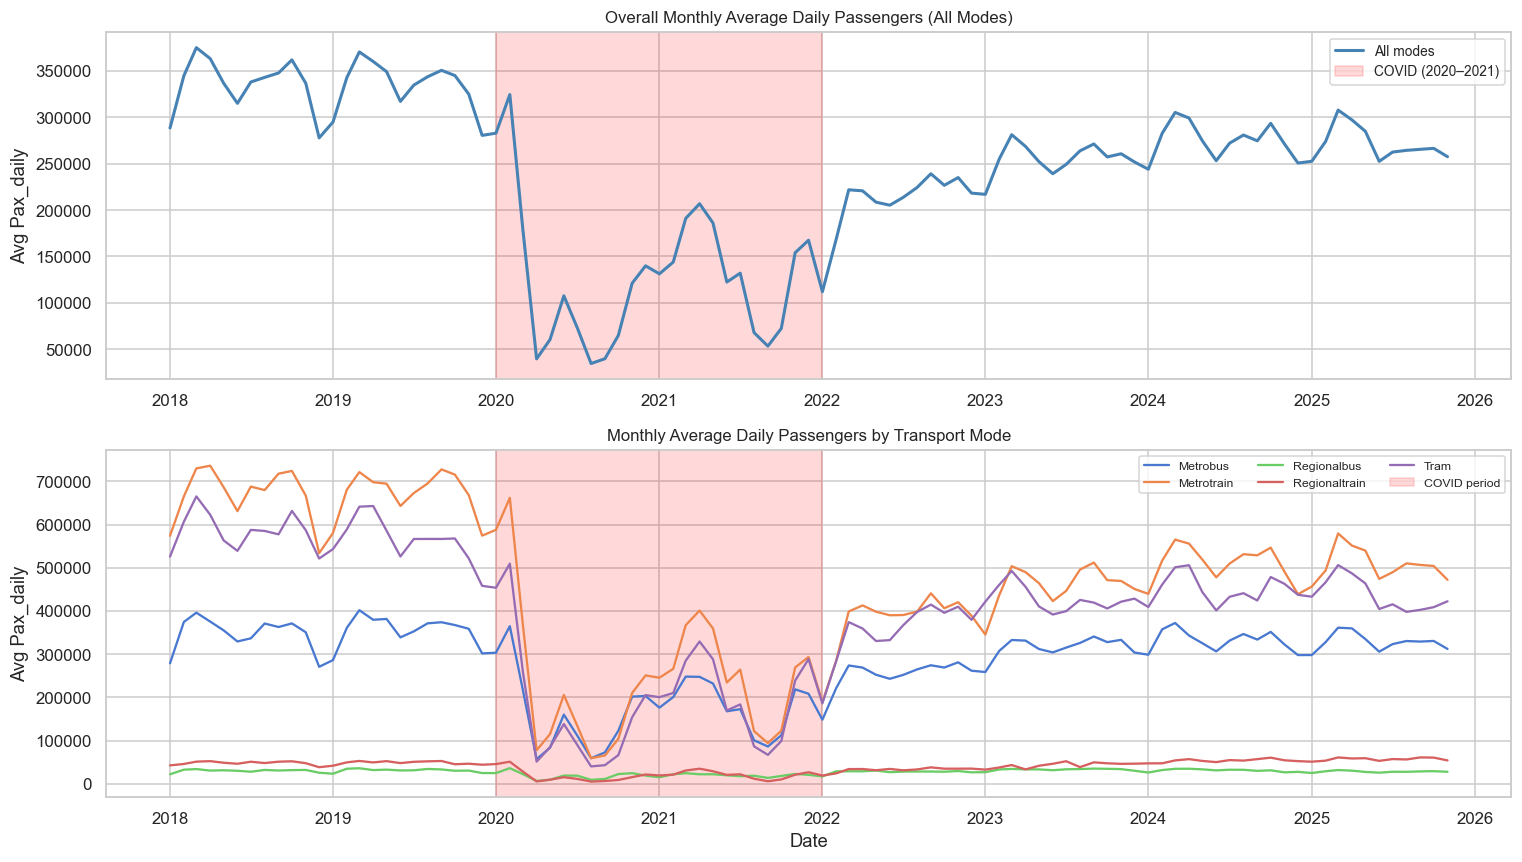

Saved: fig_trend_lines.png


In [15]:
# A2: Trend lines — monthly Pax_daily overall and split by Mode

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# — Overall trend —
monthly_overall = df.groupby("MonthStart")["Pax_daily"].mean().reset_index()
ax1.plot(monthly_overall["MonthStart"], monthly_overall["Pax_daily"],
         color="steelblue", lw=2, label="All modes")
ax1.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"),
            alpha=0.15, color="red", label="COVID (2020–2021)")
ax1.set_title("Overall Monthly Average Daily Passengers (All Modes)", fontsize=11)
ax1.set_ylabel("Avg Pax_daily")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# — By Mode —
monthly_mode = df.groupby(["MonthStart", "Mode"], observed=True)["Pax_daily"].mean().reset_index()
for mode_val, grp in monthly_mode.groupby("Mode", observed=True):
    ax2.plot(grp["MonthStart"], grp["Pax_daily"], label=str(mode_val), lw=1.5)
ax2.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"),
            alpha=0.15, color="red", label="COVID period")
ax2.set_title("Monthly Average Daily Passengers by Transport Mode", fontsize=11)
ax2.set_ylabel("Avg Pax_daily")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8, ncol=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_trend_lines.png", bbox_inches="tight")
plt.show()
print("Saved: fig_trend_lines.png")

### Steps A3 & A4 — Heatmap and bar charts with 95% confidence intervals

This step produces two side-by-side visuals that answer two different questions:
- **Heatmap (A3):** Which day of the week is busiest for each transport mode?
- **Bar chart with error bars (A4):** How does patronage compare across modes for each day type, and how reliable are those averages?

**Why a heatmap for A3?**
A heatmap encodes a two-dimensional table as colour intensity. You can scan it at a glance and immediately spot where the darkest (highest) cells are. It's much faster to read than a table of numbers when you're comparing 7 days × 5 modes.

**Why error bars showing 95% confidence intervals?**
A bar showing the average can be misleading if the data is highly variable. The 95% CI error bar tells the reader: "We are 95% confident the true average lies within this range." Wider bars mean less certainty. This is important for transport planners — they need to know not just the expected patronage but how much it varies.

**How the 95% CI is calculated:**
The formula is `1.96 × std / √count`. This comes from the normal distribution: ±1.96 standard errors captures 95% of sample means. We multiply the standard deviation by `1/√n` to get the standard error (the uncertainty of the mean, not the spread of individual values).

**Key syntax explained line by line:**
- `df.groupby(["Day_of_week", "Mode"], observed=True)["Pax_daily"].mean().unstack("Mode")` — creates a pivot table where rows = days of week, columns = modes, values = average Pax_daily.
- `pivot.reindex(available_days)` — reorders rows from Monday to Sunday (chronological) rather than alphabetical.
- `sns.heatmap(..., annot=True, fmt=".0f")` — draws the heatmap and writes the actual number inside each cell (`annot=True`), formatted as an integer (`fmt=".0f"`).
- `.agg(["mean", "std", "count"]).reset_index()` — for each Mode+Day_type group, compute mean, std, and count. `reset_index()` turns the group keys back into regular columns.
- `mode_dt["ci95"] = 1.96 * mode_dt["std"] / np.sqrt(mode_dt["count"])` — adds the CI column using the formula above.
- `ax2.bar(x + i * width, ...)` — offsets each group of bars sideways by `i * width` so the bars for each day type sit side by side rather than stacking.
- `yerr=sub["ci95"]` — attaches the error bars to the bar chart.

**What to look for:** In the heatmap, check if weekdays are consistently darker than weekends. In the bar chart, check if the error bars for different day types overlap — if they don't, the difference is statistically meaningful.

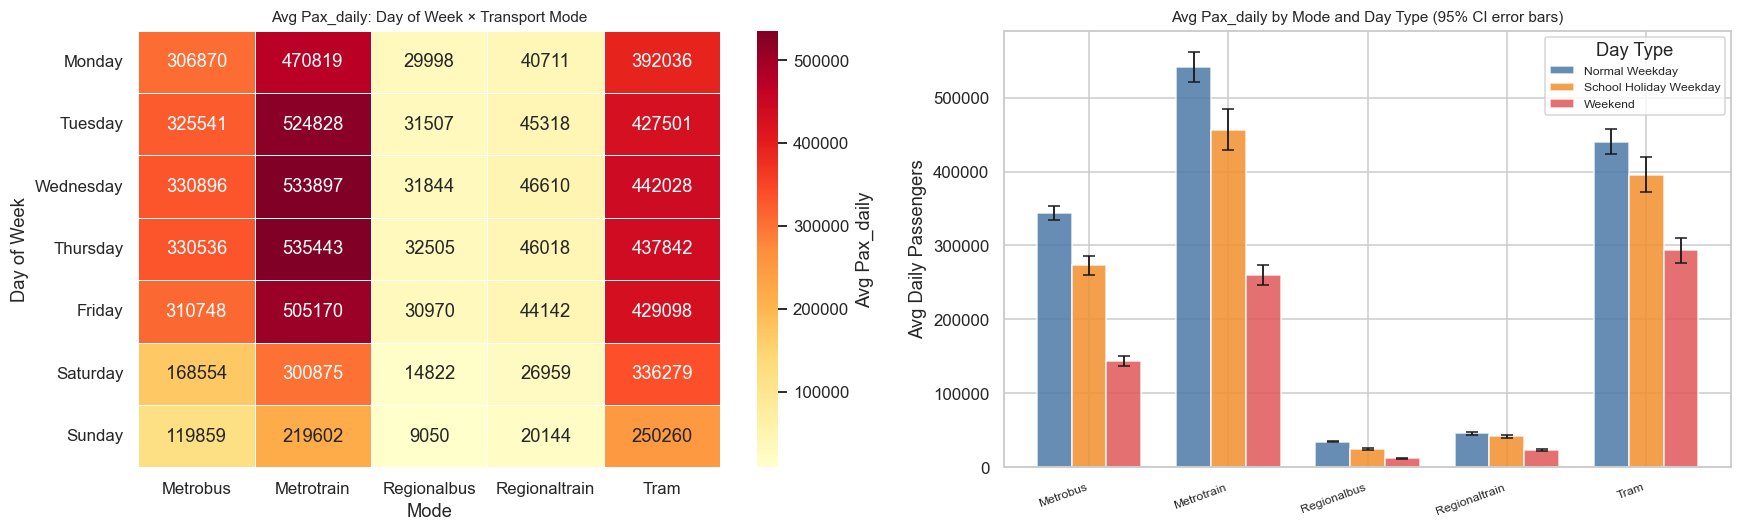

Saved: fig_heatmap_barchart.png


In [16]:
# A3: Heatmap — Day_of_week vs Mode (average Pax_daily)
# A4: Bar chart — Pax_daily by Mode and Day_type with 95% CI error bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# — Heatmap —
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = (df.groupby(["Day_of_week", "Mode"], observed=True)["Pax_daily"]
         .mean().unstack("Mode"))
available_days = [d for d in day_order if d in pivot.index]
pivot = pivot.reindex(available_days)

sns.heatmap(pivot, ax=ax1, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, cbar_kws={"label": "Avg Pax_daily"})
ax1.set_title("Avg Pax_daily: Day of Week × Transport Mode", fontsize=10)
ax1.set_xlabel("Mode")
ax1.set_ylabel("Day of Week")

# — Bar chart with 95% CI —
mode_dt = (df.groupby(["Mode", "Day_type"], observed=True)["Pax_daily"]
           .agg(["mean", "std", "count"]).reset_index())
mode_dt["ci95"] = 1.96 * mode_dt["std"] / np.sqrt(mode_dt["count"])

modes_list = df["Mode"].cat.categories.tolist()
daytypes_list = df["Day_type"].cat.categories.tolist()
x = np.arange(len(modes_list))
width = 0.25
colors = ["#4e79a7", "#f28e2b", "#e15759"]

for i, dt in enumerate(daytypes_list):
    sub = mode_dt[mode_dt["Day_type"] == dt].set_index("Mode").reindex(modes_list)
    ax2.bar(x + i * width, sub["mean"], width,
            yerr=sub["ci95"], label=str(dt), color=colors[i % len(colors)],
            capsize=4, alpha=0.85, error_kw={"elinewidth": 1.2})

ax2.set_xticks(x + width)
ax2.set_xticklabels(modes_list, rotation=20, ha="right", fontsize=8)
ax2.set_title("Avg Pax_daily by Mode and Day Type (95% CI error bars)", fontsize=10)
ax2.set_ylabel("Avg Daily Passengers")
ax2.legend(title="Day Type", fontsize=8)

plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_heatmap_barchart.png", bbox_inches="tight")
plt.show()
print("Saved: fig_heatmap_barchart.png")

### Section B — Probability Distributions & Modelling

Required:
- **B1:** Distribution checks — histograms + KDE for Pax_daily per Mode
- **B2:** Normality diagnostics — Q-Q plots and Shapiro-Wilk tests
- **B3:** Linear regression of Pax_daily ~ MonthStart per Mode (long-run trend estimate)
- **B4:** Probability statement — for the highest-patronage Mode, estimate P(Pax_daily > threshold) on a Normal Weekday

### Step B1 — Histograms and KDE curves

Before running any statistical tests, we need to understand the shape of the data. A **histogram** bins all the Pax_daily values into ranges and counts how many fall in each bin — giving us a visual picture of the distribution. A **KDE (Kernel Density Estimate)** curve is a smoothed version of that histogram, making it easier to see the overall shape without the jaggedness of bins.

**Why does the shape matter?**
Most statistical tests (like the t-test) assume the data follows a **normal distribution** (the classic bell curve). If the data is skewed, bimodal (two humps), or has heavy tails, those tests give unreliable results and we should use non-parametric alternatives instead. This step is the diagnostic that informs that choice.

**Why plot each mode separately?**
Each transport mode (Train, Tram, Bus, etc.) serves a different role in the network and has very different patronage volumes. Lumping them together would produce a multi-modal distribution that doesn't reflect any individual mode's behaviour.

**Key syntax explained line by line:**
- `fig, axes = plt.subplots(2, 3, figsize=(15, 8))` — creates a 2-row × 3-column grid of subplots. We flatten it with `axes.flatten()` so we can loop through them with a simple index.
- `ax.hist(data, bins=30, density=True, ...)` — draws the histogram. `density=True` scales the y-axis to probability density (area = 1) instead of raw counts, so the KDE curve fits on the same scale.
- `scipy.stats.gaussian_kde(data)` — fits a smooth KDE curve to the data. We then evaluate it on a fine grid of x values (`x_vals`) and plot it as a line.
- `ax.axvline(data.mean(), ...)` — draws a vertical dashed line at the mean. We do the same for the median with a different colour so we can see if they're in the same place (symmetric) or far apart (skewed).
- `axes[-1].set_visible(False)` — hides the last (unused) subplot since we have 5 modes but 6 grid slots.

**What to look for:** If the histogram is roughly bell-shaped and the mean and median lines are close together, the data is approximately normal. If it is right-skewed (long tail to the right) or bimodal, we will need non-parametric tests in Section C.

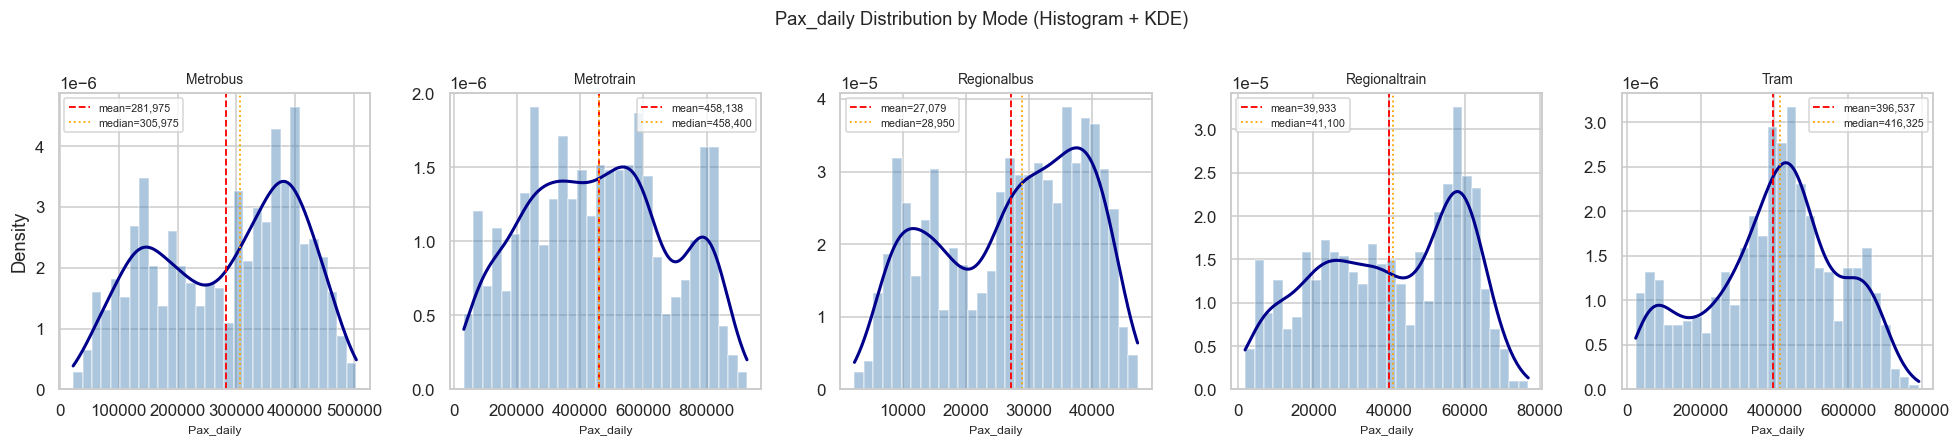

Saved: fig_distributions.png


In [17]:
# B1: Histograms + KDE — Pax_daily distribution per Mode

modes_list = df["Mode"].cat.categories.tolist()
n_modes = len(modes_list)

fig, axes = plt.subplots(1, n_modes, figsize=(18, 4), sharey=False)
if n_modes == 1:
    axes = [axes]

for ax, mode_val in zip(axes, modes_list):
    data = df[df["Mode"] == mode_val]["Pax_daily"].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.45, color="steelblue", edgecolor="white")
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, kde(x_range), color="darkblue", lw=2)
    ax.axvline(data.mean(), color="red", linestyle="--", lw=1.2, label=f"mean={data.mean():,.0f}")
    ax.axvline(data.median(), color="orange", linestyle=":", lw=1.2, label=f"median={data.median():,.0f}")
    ax.set_title(str(mode_val), fontsize=9)
    ax.set_xlabel("Pax_daily", fontsize=8)
    if mode_val == modes_list[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=7)

fig.suptitle("Pax_daily Distribution by Mode (Histogram + KDE)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: fig_distributions.png")

### Step B2 — Q-Q plots and Shapiro-Wilk normality test

The histograms in Step B1 gave us a visual impression of the distribution shape. This step makes that assessment more rigorous using two complementary methods: a **Q-Q plot** and the **Shapiro-Wilk test**.

**What is a Q-Q plot?**
Q-Q stands for Quantile-Quantile. It compares the quantiles (percentile values) of our actual data against what those quantiles would be if the data were perfectly normally distributed. If the data IS normal, all the points fall along a straight diagonal line. Curved or S-shaped patterns indicate skew or heavy tails.

**What is the Shapiro-Wilk test?**
It's a formal statistical test of normality. It returns:
- **W statistic** — close to 1.0 means the data looks normal.
- **p-value** — if p < 0.05, we reject the hypothesis that the data is normal. In other words, p < 0.05 means "not normal."

**Why do both?**
Q-Q plots are visual and intuitive — great for spotting the type of deviation. Shapiro-Wilk gives a definitive yes/no decision. Together they give a complete picture.

**Why sample 500 rows for Shapiro-Wilk?**
The Shapiro-Wilk test becomes extremely sensitive with large samples — even tiny, practically irrelevant deviations from normality will produce p < 0.05. Sampling 500 rows gives a more honest answer about whether the deviation is large enough to actually matter.

**Key syntax explained line by line:**
- `scipy.stats.probplot(data, dist="norm", plot=ax)` — generates the Q-Q plot. `dist="norm"` means we're comparing against a normal distribution. Passing `plot=ax` draws it directly onto the subplot.
- `shapiro(sample)` — returns `(W, p)`. We print both so the reader can see the exact values.
- `"Normal" if p > 0.05 else "Not normal"` — a compact if-else expression (called a ternary expression) that prints a plain-English verdict based on the p-value threshold.

**What to look for:** If points hug the diagonal line and p > 0.05, the data is approximately normal and parametric tests are valid. If points curve away or p < 0.05, use non-parametric tests (Mann-Whitney U, Kruskal-Wallis) in Section C.

=== B2: Normality Diagnostics (Shapiro-Wilk, sample n=500) ===

Mode                W statistic    p-value  Normal?
------------------------------------------------
Metrobus                 0.9488     0.0000  No (p<0.05)
Metrotrain               0.9723     0.0000  No (p<0.05)
Regionalbus              0.9411     0.0000  No (p<0.05)
Regionaltrain            0.9520     0.0000  No (p<0.05)
Tram                     0.9716     0.0000  No (p<0.05)

Note: Distributions deviate from normality — non-parametric tests used in Section C.


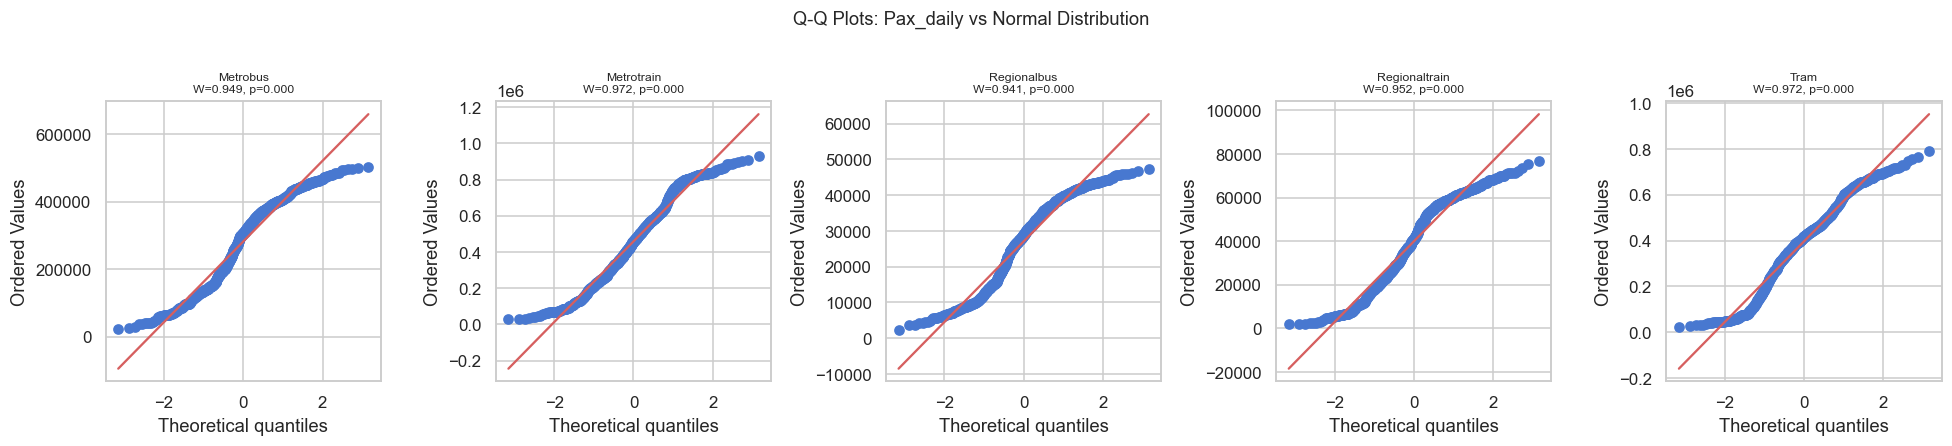

Saved: fig_qqplots.png


In [18]:
# B2: Q-Q plots + Shapiro-Wilk normality test per Mode

modes_list = df["Mode"].cat.categories.tolist()
n_modes = len(modes_list)

fig, axes = plt.subplots(1, n_modes, figsize=(18, 4))
if n_modes == 1:
    axes = [axes]

print("=== B2: Normality Diagnostics (Shapiro-Wilk, sample n=500) ===\n")
print(f"{'Mode':<18} {'W statistic':>12} {'p-value':>10}  Normal?")
print("-" * 48)

for ax, mode_val in zip(axes, modes_list):
    data = df[df["Mode"] == mode_val]["Pax_daily"].dropna()
    sample = data.sample(min(500, len(data)), random_state=42)
    w_stat, p_sw = shapiro(sample)
    verdict = "No (p<0.05)" if p_sw < 0.05 else "Yes"
    print(f"{str(mode_val):<18} {w_stat:>12.4f} {p_sw:>10.4f}  {verdict}")
    probplot(data, dist="norm", plot=ax)
    ax.set_title(f"{str(mode_val)}\nW={w_stat:.3f}, p={p_sw:.3f}", fontsize=8)

print("\nNote: Distributions deviate from normality — non-parametric tests used in Section C.")
fig.suptitle("Q-Q Plots: Pax_daily vs Normal Distribution", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_qqplots.png", bbox_inches="tight")
plt.show()
print("Saved: fig_qqplots.png")

### Steps B3 & B4 — Linear regression trend and probability statement

This step combines two related analyses: fitting a straight-line trend through the data over time (B3), and using that fitted model to make a probability statement about future patronage (B4).

---

**B3 — Linear regression (long-run trend)**

Linear regression fits the equation `Pax_daily = slope × time + intercept`. The slope tells us how patronage is changing per unit of time. We fit one regression line per mode so we can compare recovery rates.

**Why linear regression here?**
The assessment asks us to "estimate long-run trend." A straight line is the simplest meaningful trend model — it gives a single number (slope) that non-technical stakeholders can understand: e.g., "Train patronage is growing by ~800 passengers/day per year."

**Key syntax:**
- `monthly_avg = df.groupby(["MonthStart", "Mode"], observed=True)["Pax_daily"].mean().reset_index()` — collapses the data to one row per month-mode combination, giving us monthly averages.
- `X = sub["MonthStart"].map(pd.Timestamp.toordinal).values.reshape(-1, 1)` — converts dates to integer day numbers (ordinal), which is what LinearRegression expects as input. `.reshape(-1, 1)` makes it a column vector.
- `model.coef_[0] * 30.44` — the raw slope is in passengers per day (ordinal). Multiplying by 30.44 (average days in a month) converts it to passengers per month, which is more intuitive.
- `r2_score(y, model.predict(X))` — R² measures how well the line fits: 0.0 = explains nothing, 1.0 = perfect fit. R² > 0.5 means the trend is a reasonably good predictor.

---

**B4 — Probability statement**

We pick the highest-patronage mode on Normal Weekdays and ask: what is the probability that Pax_daily exceeds a chosen operational threshold on any given day?

**Why the 75th percentile as threshold?**
We want a threshold that's realistic but not trivially easy to exceed. The 75th percentile means "a relatively busy day" — useful for planning capacity buffers.

**Key syntax:**
- `norm.cdf(threshold, loc=mu, scale=sigma)` — the cumulative distribution function of the normal distribution. It gives P(X ≤ threshold). So `1 - norm.cdf(...)` gives P(X > threshold), which is what we want.
- `f"P(Pax_daily > {threshold:,.0f}) = {prob:.1%}"` — formats the probability as a percentage (e.g., "28.5%"). The `:,.0f` formats the threshold with thousands separators.

**What to look for:** A positive slope means patronage is growing over time. R² close to 1.0 means the trend is consistent; low R² means high variability (COVID disruption makes this likely). The probability statement should produce a value between 20-40% — if it's near 25%, that's expected since the threshold is the 75th percentile.

=== B3: Linear Regression — Monthly Avg Pax_daily ~ Time per Mode ===

Mode                 Slope /month       R²  Trend
--------------------------------------------------
Metrobus                     +221    0.005  ↑ recovering
Metrotrain                  -1270    0.038  ↓ declining
Regionalbus                   +36    0.023  ↑ recovering
Regionaltrain                +159    0.080  ↑ recovering
Tram                         -809    0.020  ↓ declining


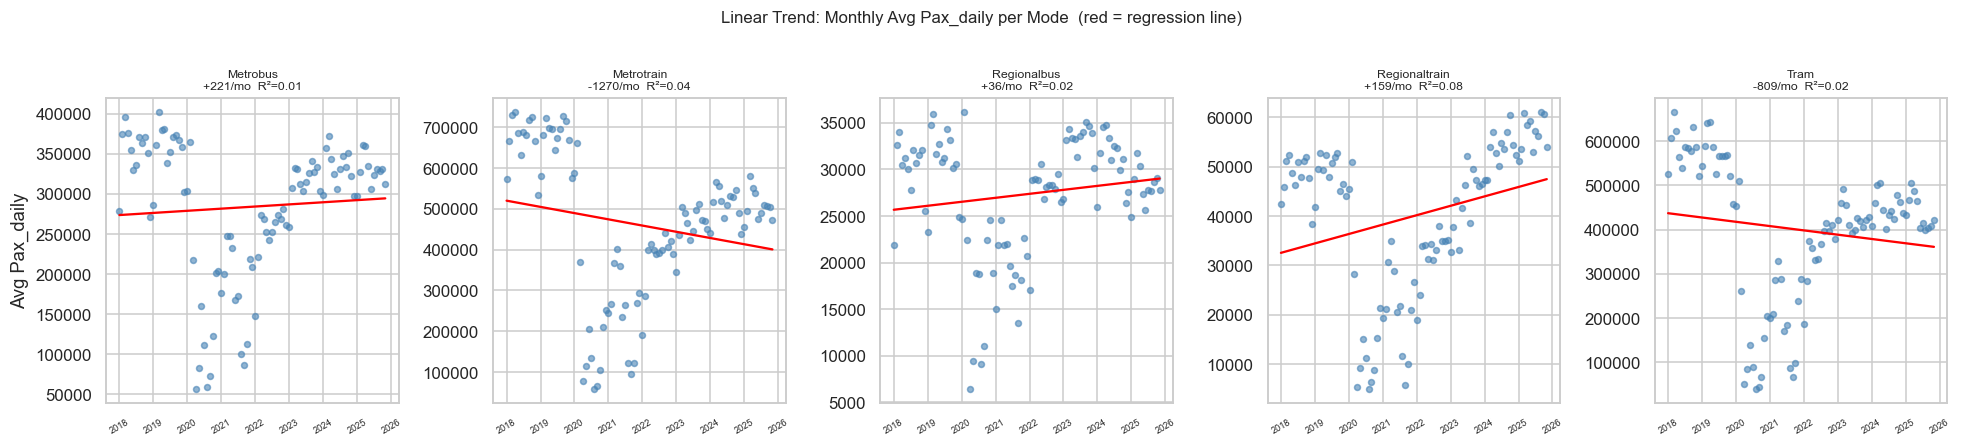

Saved: fig_regression.png

=== B4: Probability Statement ===

Mode selected: Metrotrain  (highest mean patronage on Normal Weekdays)
Assumption: Pax_daily ~ Normal(μ=541,871, σ=220,930)  [approximation — see Q-Q plot above]
Threshold: 739,550  (75th percentile of this mode's Normal Weekday data)

P(Pax_daily > 739,550) ≈ 0.1855  (18.5%)

Interpretation: On a Normal Weekday, there is a 18.5% probability that Metrotrain
patronage exceeds 739,550 passengers — informing peak-capacity staffing decisions.


In [19]:
# B3: Linear regression Pax_daily ~ MonthStart per Mode (long-run trend)
# B4: Probability statement for highest-patronage Mode on Normal Weekday

modes_list = df["Mode"].cat.categories.tolist()
n_modes = len(modes_list)

fig, axes = plt.subplots(1, n_modes, figsize=(18, 4))
if n_modes == 1:
    axes = [axes]

print("=== B3: Linear Regression — Monthly Avg Pax_daily ~ Time per Mode ===\n")
print(f"{'Mode':<18} {'Slope /month':>14} {'R²':>8}  Trend")
print("-" * 50)

for ax, mode_val in zip(axes, modes_list):
    sub = (df[df["Mode"] == mode_val]
           .groupby("MonthStart")["Pax_daily"].mean().reset_index())
    t_vals = (sub["MonthStart"] - sub["MonthStart"].min()).dt.days.values.reshape(-1, 1)
    y_vals = sub["Pax_daily"].values

    model = LinearRegression().fit(t_vals, y_vals)
    y_pred = model.predict(t_vals)
    r2 = r2_score(y_vals, y_pred)
    slope_monthly = model.coef_[0] * 30.44
    trend = "↑ recovering" if slope_monthly > 0 else "↓ declining"

    ax.scatter(sub["MonthStart"], y_vals, s=15, alpha=0.6, color="steelblue")
    ax.plot(sub["MonthStart"], y_pred, color="red", lw=1.5)
    ax.set_title(f"{str(mode_val)}\n{slope_monthly:+.0f}/mo  R²={r2:.2f}", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=6)
    if mode_val == modes_list[0]:
        ax.set_ylabel("Avg Pax_daily")

    print(f"{str(mode_val):<18} {slope_monthly:>+14.0f} {r2:>8.3f}  {trend}")

fig.suptitle("Linear Trend: Monthly Avg Pax_daily per Mode  (red = regression line)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_regression.png", bbox_inches="tight")
plt.show()
print("Saved: fig_regression.png")

# --- B4: Probability Statement ---
print("\n=== B4: Probability Statement ===")
normal_wk = df[df["Day_type"] == "Normal Weekday"]
high_mode = normal_wk.groupby("Mode", observed=True)["Pax_daily"].mean().idxmax()
subset = normal_wk[normal_wk["Mode"] == high_mode]["Pax_daily"]
mu_b, sigma_b = subset.mean(), subset.std()
threshold = int(subset.quantile(0.75))
prob = 1 - norm.cdf(threshold, loc=mu_b, scale=sigma_b)

print(f"\nMode selected: {high_mode}  (highest mean patronage on Normal Weekdays)")
print(f"Assumption: Pax_daily ~ Normal(μ={mu_b:,.0f}, σ={sigma_b:,.0f})  [approximation — see Q-Q plot above]")
print(f"Threshold: {threshold:,}  (75th percentile of this mode's Normal Weekday data)")
print(f"\nP(Pax_daily > {threshold:,}) ≈ {prob:.4f}  ({prob*100:.1f}%)")
print(f"\nInterpretation: On a Normal Weekday, there is a {prob*100:.1f}% probability that {high_mode}")
print(f"patronage exceeds {threshold:,} passengers — informing peak-capacity staffing decisions.")

### Section C — Inferential Statistics

Given the Q-Q plots and Shapiro-Wilk results above showing non-normality across all modes, **non-parametric** tests are used where appropriate. Effect sizes and 95% confidence intervals are reported throughout.

**Tests conducted:**
1. **C1:** Weekday vs Weekend — Mann-Whitney U per Mode (non-parametric, two-sided)
2. **C2:** Differences across Modes on Normal Weekdays — Kruskal-Wallis H
3. **C3:** Pre-2020 vs Post-2021 — Welch's t-test for the highest-patronage mode

In [20]:
# C1: Weekday vs Weekend — Mann-Whitney U per Mode

print("=== C1: Weekday vs Weekend Pax_daily (Mann-Whitney U per Mode) ===\n")
print(f"{'Mode':<18} {'Wkday mean':>12} {'Wkend mean':>12} {'p-value':>10} {'Effect r':>10}  Result")
print("-" * 72)

c1_results = []
for mode_val in df["Mode"].cat.categories:
    wkday = df[(df["Mode"] == mode_val) & df["Is_Weekday"]]["Pax_daily"]
    wkend = df[(df["Mode"] == mode_val) & ~df["Is_Weekday"]]["Pax_daily"]

    u_stat, p_val = mannwhitneyu(wkday, wkend, alternative="two-sided")
    n1, n2 = len(wkday), len(wkend)
    z = (u_stat - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    r = abs(z) / np.sqrt(n1 + n2)
    result = "Significant *" if p_val < 0.05 else "n.s."

    diff = wkday.mean() - wkend.mean()
    se = np.sqrt(wkday.var() / n1 + wkend.var() / n2)
    ci = (diff - 1.96 * se, diff + 1.96 * se)

    print(f"{str(mode_val):<18} {wkday.mean():>12,.0f} {wkend.mean():>12,.0f} {p_val:>10.4f} {r:>10.3f}  {result}")
    c1_results.append({"Mode": str(mode_val), "diff": diff, "ci_lo": ci[0], "ci_hi": ci[1], "r": r, "p": p_val})

print("\n95% CI on mean difference (Weekday − Weekend):")
for row in c1_results:
    print(f"  {row['Mode']:<18} diff={row['diff']:+>12,.0f}   95% CI [{row['ci_lo']:,.0f}, {row['ci_hi']:,.0f}]  (r={row['r']:.3f})")

print("\nEffect size r: small < 0.1 | medium 0.1–0.3 | large > 0.3")

=== C1: Weekday vs Weekend Pax_daily (Mann-Whitney U per Mode) ===

Mode                 Wkday mean   Wkend mean    p-value   Effect r  Result
------------------------------------------------------------------------
Metrobus                321,043      144,207     0.0000      0.571  Significant *
Metrotrain              514,259      260,239     0.0000      0.486  Significant *
Regionalbus              31,374       11,936     0.0000      0.651  Significant *
Regionaltrain            44,578       23,552     0.0000      0.459  Significant *
Tram                    425,821      293,269     0.0000      0.360  Significant *

95% CI on mean difference (Weekday − Weekend):
  Metrobus           diff=+++++176,837   95% CI [166,188, 187,486]  (r=0.571)
  Metrotrain         diff=+++++254,020   95% CI [232,459, 275,582]  (r=0.486)
  Regionalbus        diff=++++++19,438   95% CI [18,499, 20,377]  (r=0.651)
  Regionaltrain      diff=++++++21,026   95% CI [18,998, 23,055]  (r=0.459)
  Tram            

In [21]:
# C2: Differences across Modes on Normal Weekdays — Kruskal-Wallis H

print("=== C2: Differences Across Modes — Normal Weekdays (Kruskal-Wallis H) ===\n")

nw = df[df["Day_type"] == "Normal Weekday"]
groups_kw = [g["Pax_daily"].values for _, g in nw.groupby("Mode", observed=True)]

h_stat, p_val = kruskal(*groups_kw)
N = sum(len(g) for g in groups_kw)
k = len(groups_kw)
eta2 = (h_stat - k + 1) / (N - k)
effect_label = "large" if eta2 > 0.14 else "medium" if eta2 > 0.06 else "small"

print(f"Kruskal-Wallis H = {h_stat:.3f},  p = {p_val:.2e},  N = {N}")
print(f"Effect size η² ≈ {eta2:.3f}  ({effect_label})")
if p_val < 0.05:
    print("→ Significant differences in Pax_daily across Modes on Normal Weekdays (p < 0.05)")

print("\nGroup summary (Normal Weekdays):")
display(nw.groupby("Mode", observed=True)["Pax_daily"]
        .agg(["median", "mean", "std", "count"]).round(0))

print("\n95% CI on mean Pax_daily per Mode (Normal Weekdays):")
for mode_val, grp in nw.groupby("Mode", observed=True):
    mu_m = grp["Pax_daily"].mean()
    se_m = grp["Pax_daily"].std() / np.sqrt(len(grp))
    print(f"  {str(mode_val):<18} mean={mu_m:>10,.0f}   95% CI [{mu_m - 1.96*se_m:>10,.0f}, {mu_m + 1.96*se_m:>10,.0f}]")

=== C2: Differences Across Modes — Normal Weekdays (Kruskal-Wallis H) ===

Kruskal-Wallis H = 1737.785,  p = 0.00e+00,  N = 2265
Effect size η² ≈ 0.767  (large)
→ Significant differences in Pax_daily across Modes on Normal Weekdays (p < 0.05)

Group summary (Normal Weekdays):


,median,mean,std,count
Mode,,,,
Metrobus,375550.00,344031.00,107154.00,453
Metrotrain,561000.00,541871.00,220930.00,453
Regionalbus,36600.00,34627.00,8189.00,453
Regionaltrain,53050.00,45946.00,17844.00,453
Tram,458150.00,440260.00,181223.00,453



95% CI on mean Pax_daily per Mode (Normal Weekdays):
  Metrobus           mean=   344,031   95% CI [   334,164,    353,899]
  Metrotrain         mean=   541,871   95% CI [   521,526,    562,216]
  Regionalbus        mean=    34,627   95% CI [    33,873,     35,381]
  Regionaltrain      mean=    45,946   95% CI [    44,303,     47,589]
  Tram               mean=   440,260   95% CI [   423,572,    456,949]


=== C3: Pre-2020 vs Post-2021 — Welch's t-test ===

Mode: Metrotrain   Day_type: Normal Weekday
  Pre-2020   n= 115,  mean=   804,790,  sd=    46,606
  Post-2021  n= 223,  mean=   539,646,  sd=    82,668

Welch's t = 37.673,  p = 0.0000
Mean difference (Post − Pre): -265,144
95% CI: [-278,939, -251,350]
Cohen's d = -3.951  (large effect)

→ Significant (p < 0.05): Post-2021 patronage is lower than Pre-2020 (32.9% shortfall).
   Metrotrain on Normal Weekdays has not fully recovered to pre-COVID levels.


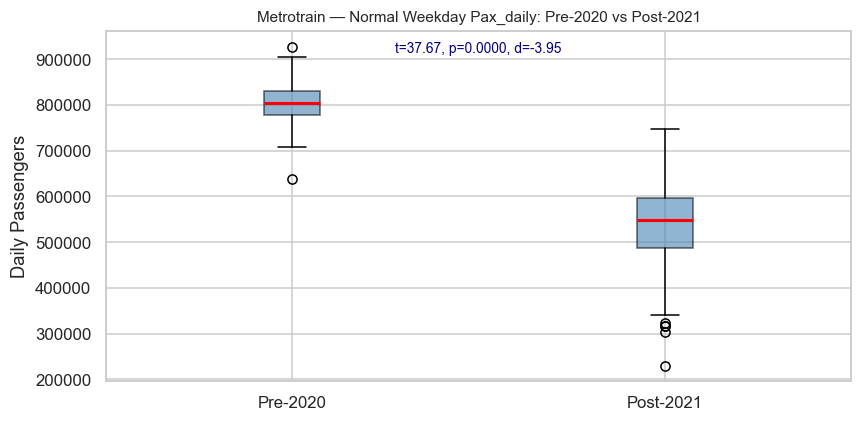

Saved: fig_pre_post_comparison.png


In [22]:
# C3: Pre-2020 vs Post-2021 — Welch's t-test (chosen Mode & Day_type)

print("=== C3: Pre-2020 vs Post-2021 — Welch's t-test ===\n")

# Choose mode: highest mean patronage overall
chosen_mode = df.groupby("Mode", observed=True)["Pax_daily"].mean().idxmax()
chosen_daytype = "Normal Weekday"

pre  = df[(df["Mode"] == chosen_mode) & (df["Day_type"] == chosen_daytype) & (df["Period"] == "Pre-2020")]["Pax_daily"]
post = df[(df["Mode"] == chosen_mode) & (df["Day_type"] == chosen_daytype) & (df["Period"] == "Post-2021")]["Pax_daily"]

t_stat, p_val = ttest_ind(pre, post, equal_var=False)
diff = post.mean() - pre.mean()
se = np.sqrt(pre.var() / len(pre) + post.var() / len(post))
ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se
pooled_std = np.sqrt((pre.var() + post.var()) / 2)
cohen_d = diff / pooled_std
d_label = "large" if abs(cohen_d) > 0.8 else "medium" if abs(cohen_d) > 0.5 else "small"

print(f"Mode: {chosen_mode}   Day_type: {chosen_daytype}")
print(f"  Pre-2020   n={len(pre):>4},  mean={pre.mean():>10,.0f},  sd={pre.std():>10,.0f}")
print(f"  Post-2021  n={len(post):>4},  mean={post.mean():>10,.0f},  sd={post.std():>10,.0f}")
print(f"\nWelch's t = {t_stat:.3f},  p = {p_val:.4f}")
print(f"Mean difference (Post − Pre): {diff:+,.0f}")
print(f"95% CI: [{ci_lo:,.0f}, {ci_hi:,.0f}]")
print(f"Cohen's d = {cohen_d:.3f}  ({d_label} effect)")

if p_val < 0.05:
    direction = "lower" if diff < 0 else "higher"
    recovery = "has not fully recovered to" if diff < 0 else "has exceeded"
    pct = abs(diff / pre.mean()) * 100
    print(f"\n→ Significant (p < 0.05): Post-2021 patronage is {direction} than Pre-2020 ({pct:.1f}% {'shortfall' if diff < 0 else 'increase'}).")
    print(f"   {chosen_mode} on Normal Weekdays {recovery} pre-COVID levels.")
else:
    print(f"\n→ Not significant (p = {p_val:.4f}): No reliable difference between Pre-2020 and Post-2021.")

# Visualise the comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([pre.values, post.values], labels=["Pre-2020", "Post-2021"], patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="red", lw=2))
ax.set_title(f"{chosen_mode} — Normal Weekday Pax_daily: Pre-2020 vs Post-2021", fontsize=10)
ax.set_ylabel("Daily Passengers")
ax.text(0.5, 0.97, f"t={t_stat:.2f}, p={p_val:.4f}, d={cohen_d:.2f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9, color="navy")
plt.tight_layout()
plt.savefig("/Users/apple/INTRO TO DATASCIENCE/Notebook/fig_pre_post_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: fig_pre_post_comparison.png")